# 🔮 Customer Churn Prediction
### End-to-End ML Pipeline — 14 Models with Full Evaluation

**What we do:**
1. Load & explore the data
2. Preprocess: LabelEncoder + OneHotEncoder + StandardScaler
3. Train 14 classifiers
4. Evaluate with every important metric
5. Compare and pick the best


## 1. Imports

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold

# Metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    matthews_corrcoef, log_loss, balanced_accuracy_score,
    RocCurveDisplay, ConfusionMatrixDisplay
)

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier,
    AdaBoostClassifier, ExtraTreesClassifier, BaggingClassifier
)
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

print("✅ All libraries imported!")


✅ All libraries imported!


## 2. Load & Explore Data

In [2]:
df = pd.read_csv("../data/raw/customer_churn.csv")

print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()


Shape: (7043, 21)

First 5 rows:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
# Data types and nulls
print("Data Types:")
print(df.dtypes)
print("\nMissing values:", df.isnull().sum().sum())


Data Types:
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

Missing values: 0


Churn Distribution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64


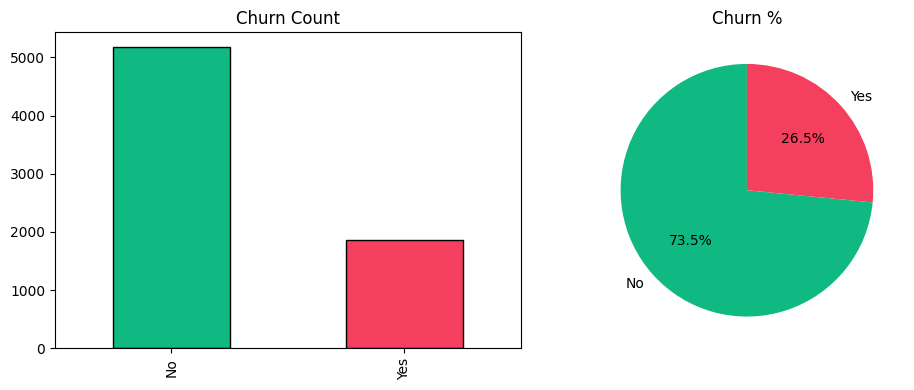

In [4]:
# Target class distribution
churn_counts = df['Churn'].value_counts()
print("Churn Distribution:")
print(churn_counts)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
churn_counts.plot.bar(ax=axes[0], color=['#10b981','#f43f5e'], edgecolor='black')
axes[0].set_title('Churn Count')
axes[0].set_xlabel('')

churn_counts.plot.pie(ax=axes[1], autopct='%1.1f%%', colors=['#10b981','#f43f5e'], startangle=90)
axes[1].set_title('Churn %')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()


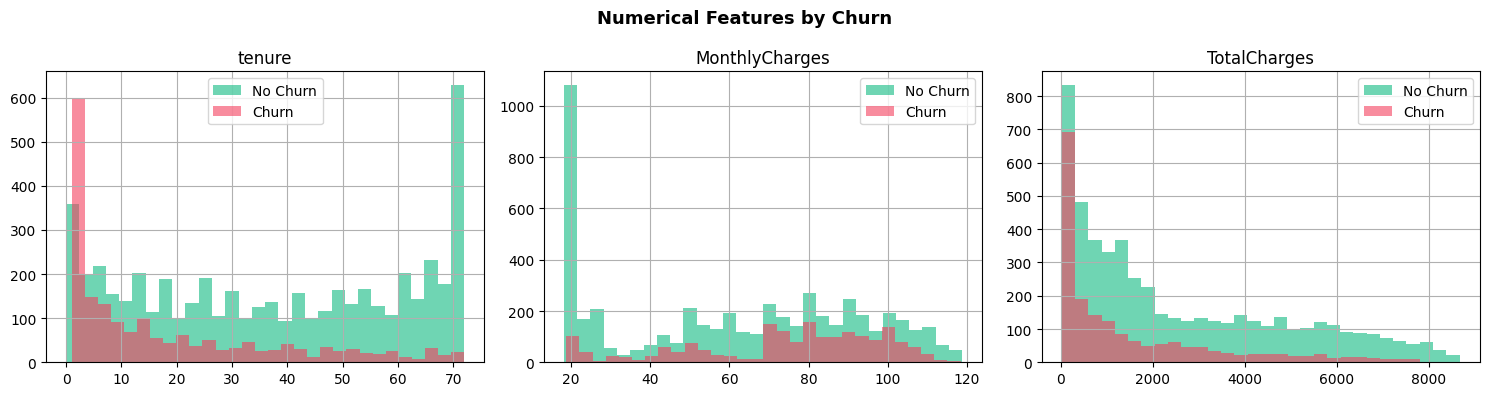

In [5]:
# Numerical features distributions
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
df[num_cols] = df[num_cols].apply(pd.to_numeric, errors='coerce')

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, num_cols):
    for val, color, label in [('No','#10b981','No Churn'), ('Yes','#f43f5e','Churn')]:
        df[df['Churn']==val][col].dropna().hist(ax=ax, alpha=0.6, color=color, label=label, bins=30)
    ax.set_title(col)
    ax.legend()
plt.suptitle('Numerical Features by Churn', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## 3. Preprocessing

**Strategy:**
- **Drop**: `customerID` (not useful)
- **LabelEncoder**: binary columns (Yes/No, Male/Female)  
- **OneHotEncoder**: multi-category columns (Contract, InternetService, etc.)
- **StandardScaler**: numeric columns (tenure, charges)


In [6]:
# Column configuration
BINARY_COLS = ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
OHE_COLS    = ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
               'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
               'Contract', 'PaymentMethod']
NUM_COLS    = ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen']
TARGET      = 'Churn'

print("Binary cols (LabelEncoder):", BINARY_COLS)
print("OHE cols (OneHotEncoder):",   OHE_COLS)
print("Numeric cols (StandardScaler):", NUM_COLS)


Binary cols (LabelEncoder): ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
OHE cols (OneHotEncoder): ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod']
Numeric cols (StandardScaler): ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen']


In [7]:
# Step 1: drop customerID
df_clean = df.drop(columns=['customerID']).copy()

# Step 2: fix TotalCharges (has spaces → NaN)
df_clean['TotalCharges'] = pd.to_numeric(df_clean['TotalCharges'], errors='coerce')
df_clean['TotalCharges'].fillna(df_clean['TotalCharges'].median(), inplace=True)

# Step 3: LabelEncode binary columns + target
le = LabelEncoder()
for col in BINARY_COLS + [TARGET]:
    df_clean[col] = le.fit_transform(df_clean[col].astype(str))
    
print("After LabelEncoding:")
print(df_clean[BINARY_COLS + [TARGET]].head())


After LabelEncoding:
   gender  Partner  Dependents  PhoneService  PaperlessBilling  Churn
0       0        1           0             0                 1      0
1       1        0           0             1                 0      0
2       1        0           0             1                 1      1
3       1        0           0             0                 0      0
4       0        0           0             1                 1      1


In [8]:
# Step 4: Split X / y
X = df_clean.drop(columns=[TARGET])
y = df_clean[TARGET]

print("X shape:", X.shape)
print("y distribution:", y.value_counts().to_dict())

# Step 5: Train/test split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\nTrain: {X_train.shape}, Test: {X_test.shape}")


X shape: (7043, 19)
y distribution: {0: 5174, 1: 1869}

Train: (5634, 19), Test: (1409, 19)


In [9]:
# Step 6: ColumnTransformer — OHE + StandardScaler
preprocessor = ColumnTransformer([
    ('ohe',   OneHotEncoder(handle_unknown='ignore', sparse_output=False), OHE_COLS),
    ('scale', StandardScaler(), NUM_COLS),
], remainder='passthrough')  # binary cols pass through as-is

X_train_t = preprocessor.fit_transform(X_train)
X_test_t  = preprocessor.transform(X_test)

print("Transformed X_train shape:", X_train_t.shape)
print("(OHE expands categories into dummy columns)")


Transformed X_train shape: (5634, 40)
(OHE expands categories into dummy columns)


## 4. Define All 14 Models

| # | Model | Type |
|---|-------|------|
| 1 | Logistic Regression | Linear |
| 2 | Decision Tree | Tree |
| 3 | Random Forest | Ensemble (Bagging) |
| 4 | Gradient Boosting | Ensemble (Boosting) |
| 5 | AdaBoost | Ensemble (Boosting) |
| 6 | Extra Trees | Ensemble (Bagging) |
| 7 | Bagging | Ensemble (Bagging) |
| 8 | SVM | Kernel |
| 9 | KNN | Instance-based |
| 10 | Naive Bayes | Probabilistic |
| 11 | LDA | Discriminant |
| 12 | QDA | Discriminant |
| 13 | XGBoost | Gradient Boosting |
| 14 | LightGBM | Gradient Boosting |


In [10]:
models = {
    "Logistic Regression":   LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree":         DecisionTreeClassifier(random_state=42),
    "Random Forest":         RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    "Gradient Boosting":     GradientBoostingClassifier(n_estimators=100, random_state=42),
    "AdaBoost":              AdaBoostClassifier(n_estimators=100, random_state=42),
    "Extra Trees":           ExtraTreesClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    "Bagging":               BaggingClassifier(n_estimators=50, random_state=42, n_jobs=-1),
    "SVM":                   SVC(probability=True, random_state=42),
    "KNN":                   KNeighborsClassifier(n_neighbors=7, n_jobs=-1),
    "Naive Bayes":           GaussianNB(),
    "LDA":                   LinearDiscriminantAnalysis(),
    "QDA":                   QuadraticDiscriminantAnalysis(),
    "XGBoost":               XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss', verbosity=0),
    "LightGBM":              LGBMClassifier(n_estimators=100, random_state=42, verbose=-1, n_jobs=-1),
}
print(f"✅ {len(models)} models ready")


✅ 14 models ready


## 5. Train & Evaluate All Models

In [11]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = []
trained = {}

for name, model in models.items():
    print(f"Training {name}...", end=' ')
    
    # Fit
    model.fit(X_train_t, y_train)
    trained[name] = model
    
    # Predict
    y_pred = model.predict(X_test_t)
    y_prob = model.predict_proba(X_test_t)[:, 1] if hasattr(model, 'predict_proba') else y_pred
    
    # Cross-validation on train
    cv_scores = cross_val_score(model, X_train_t, y_train, cv=skf, scoring='roc_auc', n_jobs=-1)
    
    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    
    results.append({
        "Model":          name,
        "Accuracy":       round(accuracy_score(y_test, y_pred), 4),
        "Bal.Accuracy":   round(balanced_accuracy_score(y_test, y_pred), 4),
        "Precision":      round(precision_score(y_test, y_pred, zero_division=0), 4),
        "Recall":         round(recall_score(y_test, y_pred, zero_division=0), 4),
        "F1":             round(f1_score(y_test, y_pred, zero_division=0), 4),
        "ROC-AUC":        round(roc_auc_score(y_test, y_prob), 4),
        "MCC":            round(matthews_corrcoef(y_test, y_pred), 4),
        "Log Loss":       round(log_loss(y_test, y_prob), 4),
        "CV_AUC_mean":    round(cv_scores.mean(), 4),
        "CV_AUC_std":     round(cv_scores.std(), 4),
        "Specificity":    round(tn/(tn+fp) if (tn+fp)>0 else 0, 4),
        "Sensitivity":    round(tp/(tp+fn) if (tp+fn)>0 else 0, 4),
    })
    print(f"ROC-AUC={results[-1]['ROC-AUC']:.4f} ✅")

results_df = pd.DataFrame(results).sort_values("ROC-AUC", ascending=False).reset_index(drop=True)
print("\n✅ All models trained!")


Training Logistic Regression... 

ValueError: Input X contains NaN.
LogisticRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

## 6. Results Summary

In [ ]:
# Full results table sorted by ROC-AUC
print("=" * 100)
print("MODEL COMPARISON — Sorted by ROC-AUC")
print("=" * 100)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)
print(results_df.to_string(index=False))


In [ ]:
# Heatmap of all metrics
fig, ax = plt.subplots(figsize=(14, 7))
plot_df = results_df.set_index('Model')[
    ['Accuracy','Bal.Accuracy','Precision','Recall','F1','ROC-AUC','MCC','Specificity','Sensitivity']
]
sns.heatmap(plot_df, annot=True, fmt='.3f', cmap='RdYlGn', ax=ax,
            linewidths=0.5, cbar_kws={'label': 'Score'})
ax.set_title('All Models — Metric Heatmap', fontsize=14, fontweight='bold')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()


## 7. ROC Curves

In [ ]:
fig, ax = plt.subplots(figsize=(10, 7))
colors = plt.cm.tab20(np.linspace(0, 1, len(trained)))

for (name, model), color in zip(trained.items(), colors):
    y_prob = model.predict_proba(X_test_t)[:, 1] if hasattr(model, 'predict_proba') else model.predict(X_test_t)
    RocCurveDisplay.from_predictions(y_test, y_prob, name=name, ax=ax, color=color, alpha=0.8)

ax.plot([0,1],[0,1],'k--', label='Random')
ax.set_title('ROC Curves — All Models', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=7)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
plt.tight_layout()
plt.show()


## 8. Metric Comparisons

In [ ]:
metrics_to_plot = ['ROC-AUC', 'F1', 'Recall', 'Precision', 'MCC']
fig, axes = plt.subplots(len(metrics_to_plot), 1, figsize=(12, 16))

for ax, metric in zip(axes, metrics_to_plot):
    sorted_df = results_df.sort_values(metric, ascending=True)
    colors_bar = ['#6366f1' if v == sorted_df[metric].max() else '#334155' for v in sorted_df[metric]]
    bars = ax.barh(sorted_df['Model'], sorted_df[metric], color=colors_bar, edgecolor='none')
    ax.set_title(metric, fontweight='bold')
    ax.set_xlim(0, 1)
    for bar, val in zip(bars, sorted_df[metric]):
        ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=8)

plt.tight_layout()
plt.show()


## 9. Confusion Matrices — Top 6 Models

In [ ]:
top6 = results_df.head(6)['Model'].tolist()
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

for ax, name in zip(axes.ravel(), top6):
    model = trained[name]
    y_pred = model.predict(X_test_t)
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred, ax=ax, colorbar=False,
        display_labels=['No Churn','Churn'],
        cmap='Blues'
    )
    ax.set_title(name, fontweight='bold')

plt.suptitle('Confusion Matrices — Top 6 Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## 10. Feature Importance — Tree-Based Models

In [ ]:
# Get feature names after OHE
ohe_features = preprocessor.named_transformers_['ohe'].get_feature_names_out(OHE_COLS).tolist()
all_features  = ohe_features + NUM_COLS + [c for c in X.columns if c not in OHE_COLS + NUM_COLS]

tree_models = {k: v for k, v in trained.items()
               if hasattr(v, 'feature_importances_')}

fig, axes = plt.subplots(1, min(3, len(tree_models)), figsize=(16, 6))
if len(tree_models) == 1:
    axes = [axes]

for ax, (name, model) in zip(axes, list(tree_models.items())[:3]):
    imp = model.feature_importances_
    top_idx = np.argsort(imp)[-15:]
    ax.barh([all_features[i] for i in top_idx], imp[top_idx], color='#6366f1')
    ax.set_title(f'{name} — Top 15 Features', fontweight='bold')
    ax.set_xlabel('Importance')

plt.tight_layout()
plt.show()


## 11. Best Model & Classification Report

In [ ]:
best_name  = results_df.iloc[0]['Model']
best_model = trained[best_name]

print(f"🏆 Best Model: {best_name}")
print(f"   ROC-AUC: {results_df.iloc[0]['ROC-AUC']}")
print(f"   F1 Score: {results_df.iloc[0]['F1']}")
print()

y_pred_best = best_model.predict(X_test_t)
print("Classification Report:")
print(classification_report(y_test, y_pred_best, target_names=['No Churn', 'Churn']))


## 12. Save Best Model

In [ ]:
import pickle

artifacts = {
    'model': best_model,
    'preprocessor': preprocessor,
    'model_name': best_name,
    'feature_names': list(X.columns)
}

with open('best_model.pkl', 'wb') as f:
    pickle.dump(artifacts, f)

print(f"✅ Saved best_model.pkl ({best_name})")
print("   Load with: pickle.load(open('best_model.pkl', 'rb'))")


## Summary

| Step | Action |
|------|--------|
| Preprocessing | LabelEncoder for binary, OneHotEncoder for categoricals, StandardScaler for numerics |
| Models trained | 14 classifiers |
| Metrics tracked | Accuracy, Balanced Acc, Precision, Recall, F1, ROC-AUC, MCC, Log Loss, Specificity, Sensitivity, CV AUC |
| Best model | Check cell above (varies by run) |

**Run the FastAPI app:**
```bash
uvicorn app:app --reload
```
Then open `index.html` in browser.
